# BasketIQ — Step 6: Cohort Analysis

**Goal of this notebook:** measure customer **retention** — do customers keep coming back after their first purchase, and how does that change over time?

A **cohort** groups customers by the month of their *first* purchase (e.g. everyone who first bought in January 2011 is the "Jan 2011 cohort"). We then track, month by month, what percentage of each cohort is still buying. This reveals retention patterns that a single overall metric (like total monthly revenue) can hide — for example, whether new customers stick around or churn after one purchase.

## 1. Import libraries and load the cleaned data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)

In [2]:
PROCESSED_DATA_PATH = Path('..') / 'data' / 'processed' / 'online_retail_clean.csv'

df = pd.read_csv(PROCESSED_DATA_PATH, parse_dates=['InvoiceDate'])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 2. Assign each customer to a cohort

A customer's cohort is the **month of their very first purchase** in the dataset. We compute this once per `CustomerID` and attach it back to every one of their transactions.

In [3]:
# Truncate every transaction date down to its month (e.g. 2011-03-15 -> 2011-03-01)
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M').dt.to_timestamp()

# For each customer, find the month of their first ever purchase
cohort_month = df.groupby('CustomerID')['InvoiceMonth'].transform('min')
df['CohortMonth'] = cohort_month

df[['CustomerID', 'InvoiceMonth', 'CohortMonth']].head()

,CustomerID,InvoiceMonth,CohortMonth
0,17850,2010-12-01,2010-12-01
1,17850,2010-12-01,2010-12-01
2,17850,2010-12-01,2010-12-01
3,17850,2010-12-01,2010-12-01
4,17850,2010-12-01,2010-12-01


## 3. Calculate "cohort index" (months since first purchase)

Instead of comparing raw calendar months (which makes cohorts hard to line up), we calculate how many months have passed between a customer's first purchase and each transaction. A `CohortIndex` of `0` means "the month they first bought", `1` means "one month later", and so on. This lets us stack cohorts of different starting months on the same timeline.

In [4]:
# Difference in years and months between the transaction month and the cohort (first purchase) month
year_diff = df['InvoiceMonth'].dt.year - df['CohortMonth'].dt.year
month_diff = df['InvoiceMonth'].dt.month - df['CohortMonth'].dt.month

df['CohortIndex'] = year_diff * 12 + month_diff + 1  # +1 so the first month is index 1, not 0

df[['CustomerID', 'CohortMonth', 'InvoiceMonth', 'CohortIndex']].head()

,CustomerID,CohortMonth,InvoiceMonth,CohortIndex
0,17850,2010-12-01,2010-12-01,1
1,17850,2010-12-01,2010-12-01,1
2,17850,2010-12-01,2010-12-01,1
3,17850,2010-12-01,2010-12-01,1
4,17850,2010-12-01,2010-12-01,1


## 4. Build the cohort table

We count the number of **unique customers** active in each (CohortMonth, CohortIndex) combination, then reshape it into a matrix: one row per cohort, one column per month-since-first-purchase.

In [5]:
cohort_data = (
    df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID']
    .nunique()
    .reset_index()
)

cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

cohort_counts

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02-01,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03-01,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04-01,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05-01,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06-01,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Convert counts to retention percentages

Raw customer counts aren't directly comparable across cohorts of different sizes. We divide every value in a row by that row's `CohortIndex = 1` value (the cohort's original size), turning the table into **percentage retained**.

In [6]:
cohort_sizes = cohort_counts[1]  # number of customers in each cohort's first month

retention = cohort_counts.divide(cohort_sizes, axis=0) * 100

retention.round(1)

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,100.0,36.6,32.3,38.4,36.3,39.8,36.3,34.9,35.4,39.5,37.4,50.3,26.6
2011-01-01,100.0,22.1,26.6,23.0,32.1,28.8,24.7,24.2,30.0,32.6,36.5,11.8,NaN
2011-02-01,100.0,18.7,18.7,28.4,27.1,24.7,25.3,27.9,24.7,30.5,6.8,NaN,NaN
2011-03-01,100.0,15.0,25.2,19.9,22.3,16.8,26.8,23.0,27.9,8.6,NaN,NaN,NaN
2011-04-01,100.0,21.3,20.3,21.0,19.7,22.7,21.7,26.0,7.3,NaN,NaN,NaN,NaN
2011-05-01,100.0,19.0,17.3,17.3,20.8,23.2,26.4,9.5,NaN,NaN,NaN,NaN,NaN
2011-06-01,100.0,17.4,15.7,26.4,23.1,33.5,9.5,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,100.0,18.1,20.7,22.3,27.1,11.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,100.0,20.7,24.9,24.3,12.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Visualize retention with a heatmap

A heatmap makes the pattern immediately visible: darker/brighter cells mean higher retention. Reading down a column shows how retention at that "month number" compares across different starting cohorts; reading across a row shows how a single cohort decays over time.

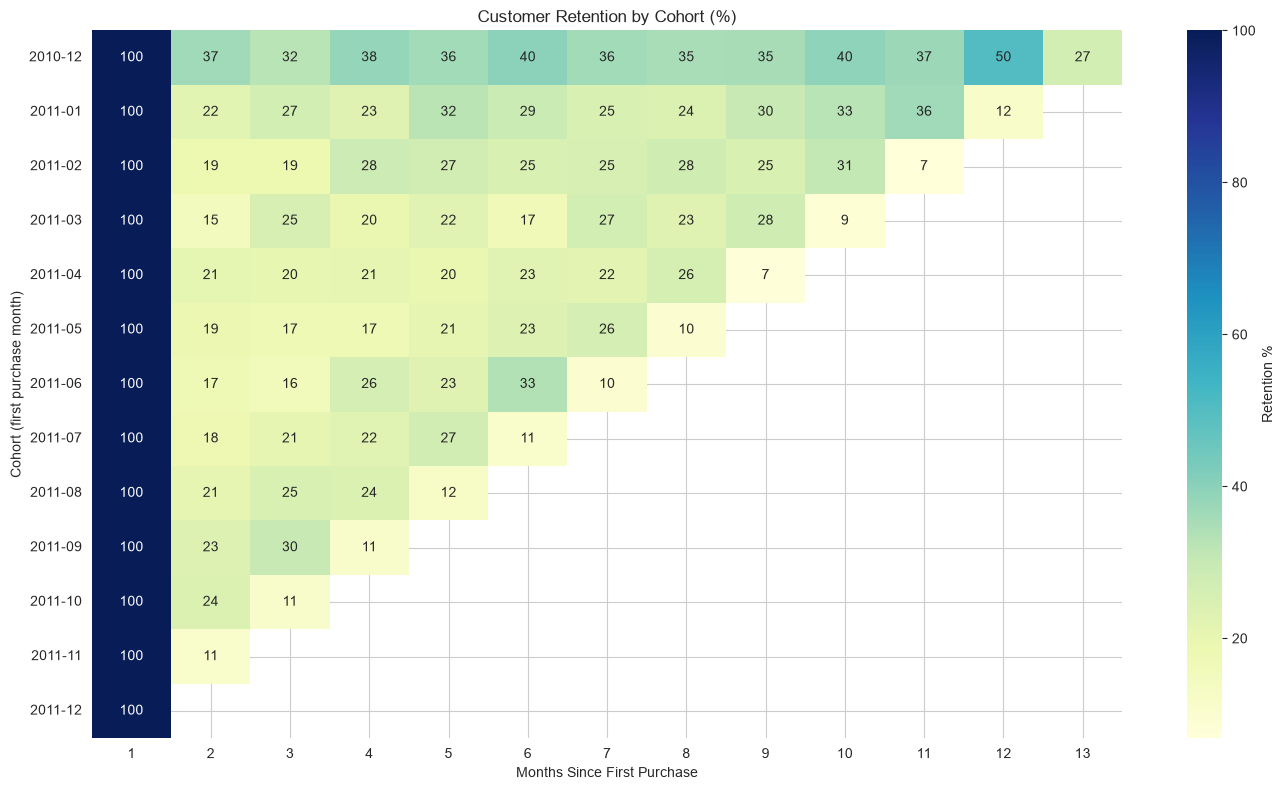

In [7]:
fig, ax = plt.subplots(figsize=(14, 8))

# Format the cohort month labels as 'YYYY-MM' for readability
retention.index = retention.index.strftime('%Y-%m')

sns.heatmap(retention, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Retention %'})
ax.set_title('Customer Retention by Cohort (%)')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort (first purchase month)')
plt.tight_layout()
plt.show()

## 7. Average retention curve

Averaging retention across all cohorts at each month-since-first-purchase gives a single curve that summarizes the "typical" customer retention pattern — useful for a one-line takeaway like *"on average, only X% of customers are still active 3 months after their first purchase."*

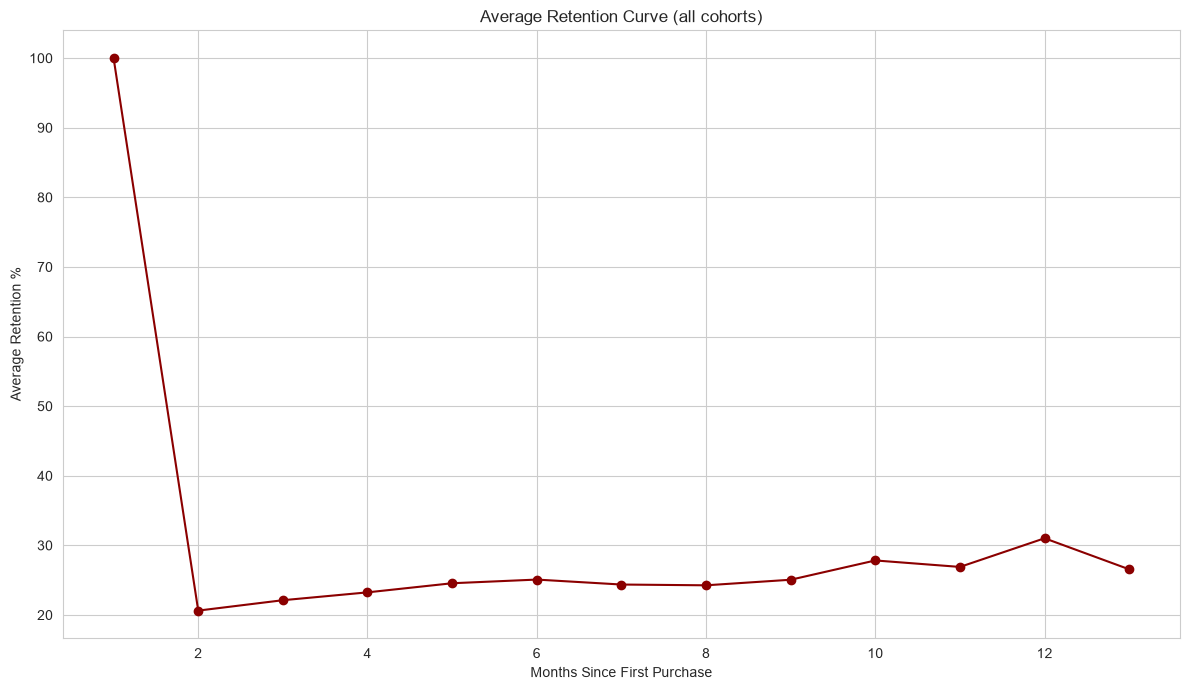

Average retention by month:
CohortIndex
1     100.0
2      20.6
3      22.1
4      23.2
5      24.6
6      25.1
7      24.4
8      24.3
9      25.1
10     27.8
11     26.9
12     31.0
13     26.6
dtype: float64


In [8]:
average_retention = retention.mean(axis=0)

fig, ax = plt.subplots()
average_retention.plot(kind='line', marker='o', ax=ax, color='darkred')
ax.set_title('Average Retention Curve (all cohorts)')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Average Retention %')
plt.tight_layout()
plt.show()

print('Average retention by month:')
print(average_retention.round(1))

## 8. Save the cohort retention table

In [9]:
OUTPUT_PATH = Path('..') / 'data' / 'processed' / 'cohort_retention.csv'

retention.to_csv(OUTPUT_PATH)
print(f'Saved cohort retention table to: {OUTPUT_PATH.resolve()}')

Saved cohort retention table to: D:\New folder\BasketIQ\data\processed\cohort_retention.csv
